In [2]:
import pandas as pd
from google.colab import auth
import gspread
from google.auth import default

# 1. Authenticate your Google account inside Colab
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

# 2. Open the Google Sheet via its URL
spreadsheet_url = "https://docs.google.com/spreadsheets/d/1vr6aRM84fabb-c6RDUAIJKt02c2TEcvBHVm5mKqKiYU/edit?usp=sharing"
sh = gc.open_by_url(spreadsheet_url)

# 3. Select the worksheet (e.g., the first sheet or by name 'Telecom_Customer_Churn')
worksheet = sh.worksheet("Telecom_Customer_Churn")

# 4. Convert all records into a Pandas DataFrame
data = worksheet.get_all_records()
df = pd.DataFrame(data)

print("--- Google Sheet Successfully Loaded into DataFrame ---")
print("Dataset Shape:", df.shape)
display(df.head())

--- Google Sheet Successfully Loaded into DataFrame ---
Dataset Shape: (1500, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("--- Missing Values Summary ---")
print(df.isnull().sum())

print("\n--- Target Variable Distribution (Churn) ---")
if 'Churn' in df.columns:
    print(df['Churn'].value_counts(normalize=True) * 100)
else:
    print("Column 'Churn' not found. Check your exact column names.")

print("\n--- Statistical Summary ---")
display(df.describe())

--- Missing Values Summary ---
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

--- Target Variable Distribution (Churn) ---
Churn
No     73.6
Yes    26.4
Name: proportion, dtype: float64

--- Statistical Summary ---


,SeniorCitizen,tenure,MonthlyCharges
count,1500.000000,1500.000000,1500.000000
mean,0.160667,31.944667,66.319533
std,0.367346,24.513878,29.767135
min,0.000000,0.000000,18.700000
25%,0.000000,9.000000,43.725000
50%,0.000000,28.000000,73.700000
75%,0.000000,55.000000,90.150000
max,1.000000,72.000000,116.250000


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Convert 'TotalCharges' to numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Define target and features
target = 'Churn'
X = df.drop(columns=[target], errors='ignore')
y = df[target].apply(lambda x: 1 if str(x).lower() in ['yes', '1', 'true'] else 0)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Preprocessing for numeric and categorical columns
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# XGBoost Pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(eval_metric='logloss', random_state=42)) # Removed deprecated use_label_encoder
])

print("--- Training Model ---")
model.fit(X_train, y_train)

print("\n--- Evaluation & Predictions ---")
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

--- Training Model ---

--- Evaluation & Predictions ---

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.86      0.85       221
           1       0.58      0.57      0.58        79

    accuracy                           0.78       300
   macro avg       0.72      0.71      0.71       300
weighted avg       0.78      0.78      0.78       300

ROC-AUC Score: 0.8151


/tmp/ipykernel_4124/3602015255.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='Set2')


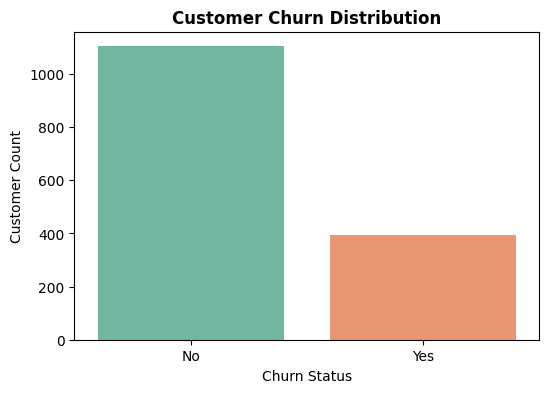

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Customer Churn Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Churn Status', fontsize=10)
plt.ylabel('Customer Count', fontsize=10)
plt.show()

/tmp/ipykernel_4124/3147412599.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Pastel1')


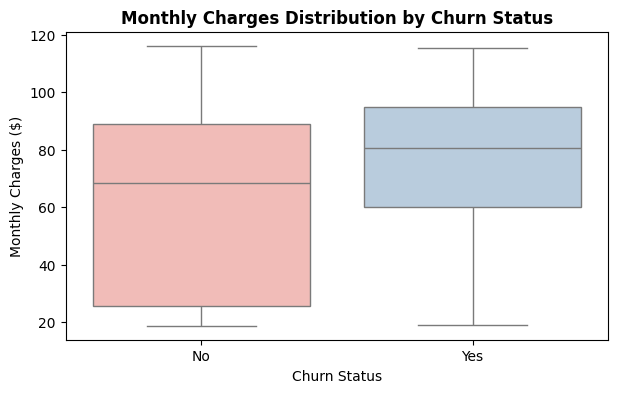

In [8]:
plt.figure(figsize=(7, 4))
# Note: Ensure 'MonthlyCharges' and 'Churn' match your exact column names
if 'MonthlyCharges' in df.columns and 'Churn' in df.columns:
    sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Pastel1')
    plt.title('Monthly Charges Distribution by Churn Status', fontsize=12, fontweight='bold')
    plt.xlabel('Churn Status', fontsize=10)
    plt.ylabel('Monthly Charges ($)', fontsize=10)
    plt.show()
else:
    print("Columns 'MonthlyCharges' or 'Churn' not found in DataFrame.")

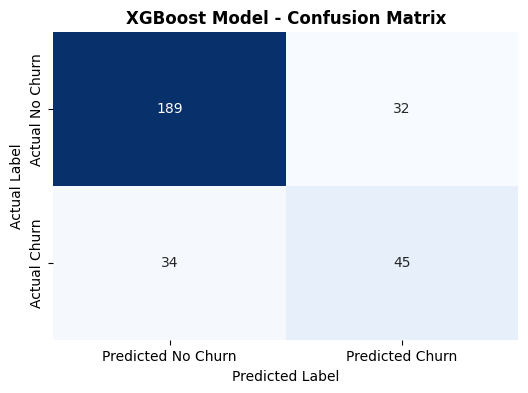

In [9]:
from sklearn.metrics import confusion_matrix

# Generates confusion matrix from previous predictions
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.title('XGBoost Model - Confusion Matrix', fontsize=12, fontweight='bold')
plt.ylabel('Actual Label', fontsize=10)
plt.xlabel('Predicted Label', fontsize=10)
plt.show()

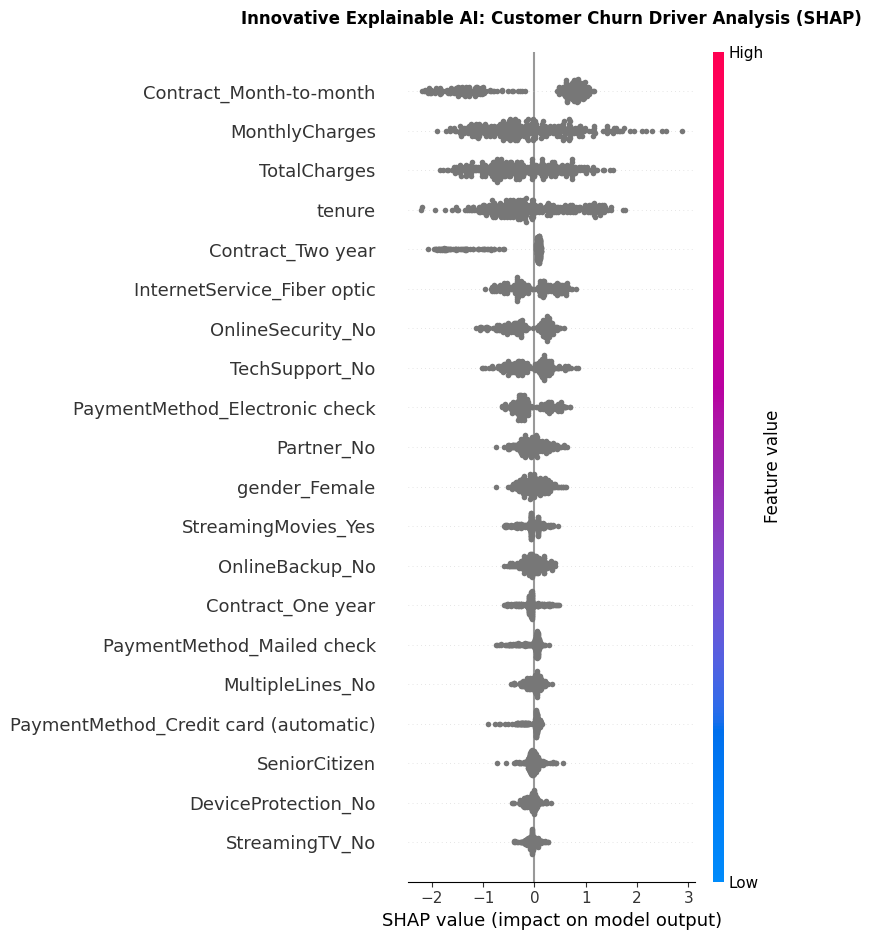

In [10]:
# Install and import SHAP for advanced Explainable AI visualization
!pip install -q shap
import shap
import matplotlib.pyplot as plt

# Extract the trained XGBoost model and preprocessor from your pipeline
xgb_model = model.named_steps['classifier']
preprocessor = model.named_steps['preprocessor']

# Transform the test data using your pipeline's preprocessor
X_test_transformed = preprocessor.transform(X_test)

# Retrieve feature names after One-Hot Encoding
numeric_feat_list = list(numeric_features)
try:
    cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
    encoded_cat_features = list(cat_encoder.get_feature_names_out(categorical_features))
    all_feature_names = numeric_feat_list + encoded_cat_features
except:
    all_feature_names = [f"feature_{i}" for i in range(X_test_transformed.shape[1])]

# Calculate SHAP values using TreeExplainer
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_transformed)

# Generate innovative SHAP summary visualization
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_transformed, feature_names=all_feature_names, show=False)
plt.title('Innovative Explainable AI: Customer Churn Driver Analysis (SHAP)', fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()